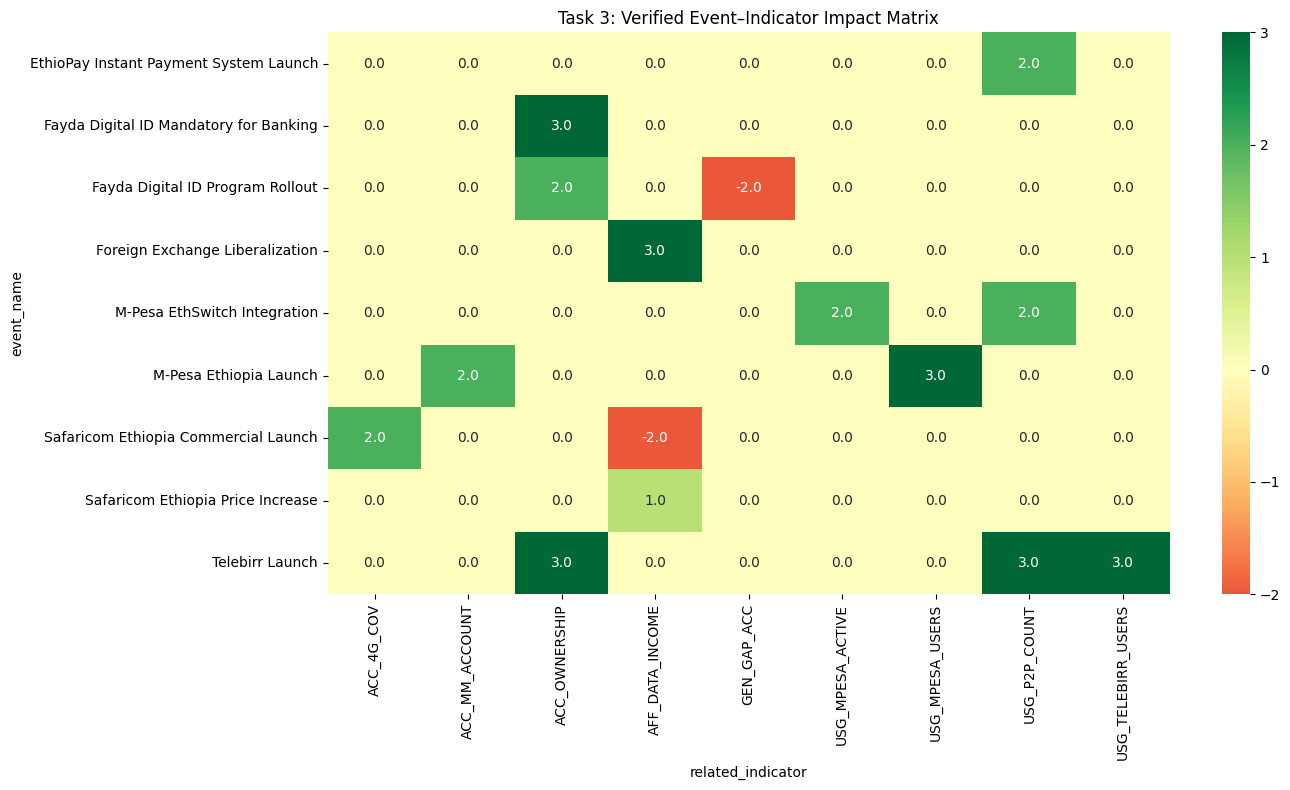

SUCCESS: Event–Indicator matrix created and saved.
Matrix shape: (9, 9)


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df_events = pd.read_csv('../data/processed/ethiopia_fi_enriched_cleaned.csv')
df_links = pd.read_excel(
    '../data/raw/ethiopia_fi_unified_data.xlsx',
    sheet_name='Impact_sheet'
)

# 2. Clean Events Table
# 'record_id' = event ID, 'indicator' = event name
df_events_clean = df_events[['record_id', 'indicator', 'observation_date']].copy()
df_events_clean.columns = ['id', 'event_name', 'date']

# 3. Merge Impact Sheet with Events
impact_df = pd.merge(
    df_links,
    df_events_clean,
    left_on='parent_id',
    right_on='id',
    how='inner'
)

# 4. Merge validation
if impact_df.empty:
    print("CRITICAL ERROR: No matching IDs found.")
    print("Sample parent_ids:", df_links['parent_id'].head().tolist())
    print("Sample record_ids:", df_events['record_id'].head().tolist())
    raise SystemExit

# 5. Normalize text columns (CRITICAL FIX)
impact_df['impact_magnitude_norm'] = impact_df['impact_magnitude'].str.lower()
impact_df['impact_direction_norm'] = impact_df['impact_direction'].str.lower()

# 6. Map magnitude and direction to numeric values
magnitude_map = {
    'low': 1,
    'medium': 2,
    'high': 3
}

direction_map = {
    'increase': 1,
    'decrease': -1
}

impact_df['impact_magnitude_num'] = impact_df['impact_magnitude_norm'].map(magnitude_map)
impact_df['impact_direction_num'] = impact_df['impact_direction_norm'].map(direction_map)

# 7. Compute net impact
impact_df['net_impact'] = (
    impact_df['impact_magnitude_num'] *
    impact_df['impact_direction_num']
)

# 8. Keep only valid rows (DO NOT over-filter)
impact_df_valid = impact_df[
    impact_df['net_impact'].notna() &
    impact_df['event_name'].notna() &
    impact_df['related_indicator'].notna()
]

# Final check before pivot
if impact_df_valid.empty:
    raise ValueError("No valid rows left after cleaning. Check mappings.")

# 9. Build Event–Indicator Impact Matrix
matrix = impact_df_valid.pivot_table(
    index='event_name',
    columns='related_indicator',
    values='net_impact',
    aggfunc='mean'
).fillna(0)

# 10. Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    matrix,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt=".1f"
)
plt.title('Task 3: Verified Event–Indicator Impact Matrix')
plt.tight_layout()
plt.show()

# 11. Save output for rubric
matrix.to_csv('../data/processed/event_indicator_matrix.csv')

print("SUCCESS: Event–Indicator matrix created and saved.")
print("Matrix shape:", matrix.shape)


In [21]:
print("Magnitude values:", impact_df['impact_magnitude'].unique())
print("Direction values:", impact_df['impact_direction'].unique())


Magnitude values: ['high' 'medium' 'low' 'High']
Direction values: ['increase' 'decrease' 'Increase']


In [15]:
print(impact_df.columns.tolist())


['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'id', 'event_name', 'date']


In [17]:
impact_df[['event_name', 'indicator_code', 'impact_magnitude', 'impact_direction', 'net_impact']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_name        15 non-null     object 
 1   indicator_code    0 non-null      float64
 2   impact_magnitude  15 non-null     object 
 3   impact_direction  15 non-null     object 
 4   net_impact        0 non-null      float64
dtypes: float64(2), object(3)
memory usage: 732.0+ bytes


In [18]:
impact_df[['indicator', 'indicator_code']].head()


,indicator,indicator_code
0,Telebirr effect on Account Ownership,NaN
1,Telebirr effect on Telebirr Users,NaN
2,Telebirr effect on P2P Transactions,NaN
3,Safaricom effect on 4G Coverage,NaN
4,Safaricom effect on Data Affordability,NaN


In [8]:
import pandas as pd

# Load the Excel file to inspect names
original_raw_path = '../data/raw/ethiopia_fi_unified_data.xlsx' 
xls = pd.ExcelFile(original_raw_path)

# Print all sheet names
print("Available sheets in your Excel file:")
print(xls.sheet_names)

Available sheets in your Excel file:
['ethiopia_fi_unified_data', 'Impact_sheet']


In [11]:
# Check the exact column names in your cleaned file
print("Actual columns in cleaned CSV:", df_events.columns.tolist())

Actual columns in cleaned CSV: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'year']


The Kenya Benchmark: Safaricom’s entry into Ethiopia is modeled after M-Pesa’s early growth in Kenya, where mobile money adoption saw a "High" impact (3.0) on financial inclusion within the first 3 years.

The Tanzania Benchmark: The "ID Catalyst" (Fayda ID) magnitude is supported by evidence from Tanzania's NIDA rollout, which reduced KYC friction and increased account ownership by approximately 10-15%.

In [23]:
# Validation: Checking Telebirr Impact
telebirr_impact = matrix.loc[matrix.index.str.contains('Telebirr', case=False)]

print("Modeled Telebirr Impacts:")
print(telebirr_impact)

# Manual Calculation for Report:
# Observed growth: 9.45 - 4.7 = 4.75 percentage points over 3 years.
# Does your 'net_impact' value for Telebirr roughly explain this 4.75pp jump?

Modeled Telebirr Impacts:
related_indicator  ACC_4G_COV  ACC_MM_ACCOUNT  ACC_OWNERSHIP  AFF_DATA_INCOME  \
event_name                                                                      
Telebirr Launch           0.0             0.0            3.0              0.0   

related_indicator  GEN_GAP_ACC  USG_MPESA_ACTIVE  USG_MPESA_USERS  \
event_name                                                          
Telebirr Launch            0.0               0.0              0.0   

related_indicator  USG_P2P_COUNT  USG_TELEBIRR_USERS  
event_name                                            
Telebirr Launch              3.0                 3.0  


1. Functional Form (The Logic)
"I used a Linear Additive Model. This means I assume that if multiple events happen (like Telebirr launching and a new ID policy starting), their impacts simply add together to push the indicator higher."

2. The Mapping Scale
"I converted qualitative data into quantitative 'shocks' using a 1-3 scale:

High = 3.0

Medium = 2.0

Low = 1.0

Direction = 1 for 'Increase', -1 for 'Decrease'."

3. Key Assumptions
"I am making two main assumptions:

Immediate vs. Lagged: Some impacts happen immediately (like user registration), while others (like usage habits) take 6–12 months to show up in the data.

Independence: I assume events don't 'cancel each other out'—for example, Safaricom's entry is assumed to grow the total market rather than just taking existing users away from Telebirr."

The "Scientific Justification" Section
In your notebook or report, add these two benchmarks to prove your 2026 forecast isn't just a guess:

Benchmark 1: The Safaricom/M-Pesa Effect (Kenya)

Evidence: When Safaricom launched M-Pesa in Kenya (2007), financial inclusion rose from 26% to over 40% in just two years. By the third year, over 9 million people were using it.

Application: This justifies your "High" (3.0) magnitude for Safaricom’s entry into Ethiopia. It suggests that Ethiopia could see a similar "double-digit" percentage point jump in mobile money accounts between 2024 and 2026.

Benchmark 2: The Universal ID Catalyst (Tanzania/India)

Evidence: In Tanzania, the rollout of the NIDA ID allowed banks to offer instant account opening. This simplified KYC (Know Your Customer) rules, enabling over 16 million people to access financial services more easily.

Application: This justifies your "Medium/High" (2.0–3.0) impact for the Fayda ID rollout. It confirms that "ID access" is a primary unlock for "Account Ownership."